In [1]:
import sys, os; sys.path.append(os.path.dirname(os.getcwd())) 

from mpl_toolkits import mplot3d

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
from tqdm import tqdm
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from sklearn.utils.validation import check_is_fitted
from sklearn.preprocessing import MinMaxScaler

from pyfrechet.metric_spaces import MetricData, Sphere

INFO: Using numpy backend


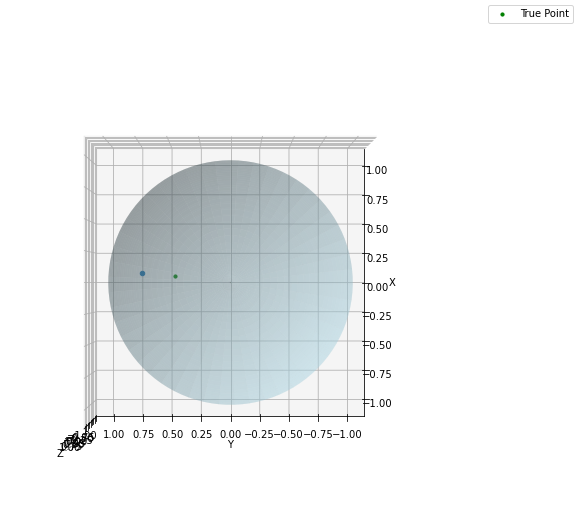

In [59]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import vonmises_fisher

# Function defining the regression mean m_0(theta) on S^2
def m_0(theta, mu):
    """
    Compute the regression mean on S^2.
    
    Parameters:
    theta : array-like
        Angles in [0, 2pi) that parameterize the great circle.
    mu : array-like, shape (2,)
        A unit vector defining the orientation of the great circle.
    
    Returns:
    array, shape (n, 3)
        The mean directions on S^2.
    """
    theta = np.asarray(theta)
    mu = np.asarray(mu)
    assert mu.shape == (2,) and np.isclose(np.linalg.norm(mu), 1), "mu must be a unit vector in R^2"
    
    x1 = np.cos(theta)
    x2 = np.sin(theta) * mu[0]
    x3 = np.sin(theta) * mu[1]
    
    return np.column_stack((x1, x2, x3))

# Function to generate vMF samples
def simulate_data(kappa, mu, theta_samples):
    """
    Generate samples from the von Mises-Fisher distribution on S^2.
    
    Parameters:
    sample_size : int
        Number of samples to generate.
    kappa : float
        Concentration parameter of the vMF distribution.
    mu : array-like, shape (2,)
        The unit vector defining the great circle.
    
    Returns:
    dict
        A dictionary containing input angles and generated samples.
    """
    mean_directions = m_0(theta_samples, mu)  # Compute means on S^2
    
    samples = [vonmises_fisher(mean, kappa).rvs() for mean in mean_directions]
    
    return theta_samples, np.array(samples)

mu = np.array([1/np.sqrt(2), 1/np.sqrt(2)])  # Fixed unit vector in R^2


# Create directory for saving samples
save_folder = os.path.join(os.getcwd(), 'simulations_sphere', 'data')
os.makedirs(save_folder, exist_ok=True)

np.random.seed(1000)
sample_size = 1000
kappa = 200
theta_samples = np.random.uniform(0, 2 * np.pi, sample_size)  # Random angles
theta, Y = simulate_data(kappa, mu, theta_samples)
Y = Y.reshape(-1, 3)
# Plotting the unit sphere
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a mesh grid for the unit sphere
u = np.linspace(0, np.pi, 100)
v = np.linspace(0, 2 * np.pi, 100)
u, v = np.meshgrid(u, v)

x_sphere = np.sin(u) * np.cos(v)
y_sphere = np.sin(u) * np.sin(v)
z_sphere = np.cos(u)

# Plot the sphere surface
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.3)

# Plot the von Mises-Fisher samples on the sphere
#ax.scatter(Y[:, 0], Y[:, 1], Y[:, 2], color='r', s=5, label="vMF Samples")
ax.scatter(0.05, 0.45, 0.45, color = 'green', s = 10, label = 'True Point')
ax.scatter(0.07832604, 0.7049344 , 0.7049344 )
# Set labels and view
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.view_init(elev=90, azim=180)  # Adjust view angle

fig.legend()
plt.show()

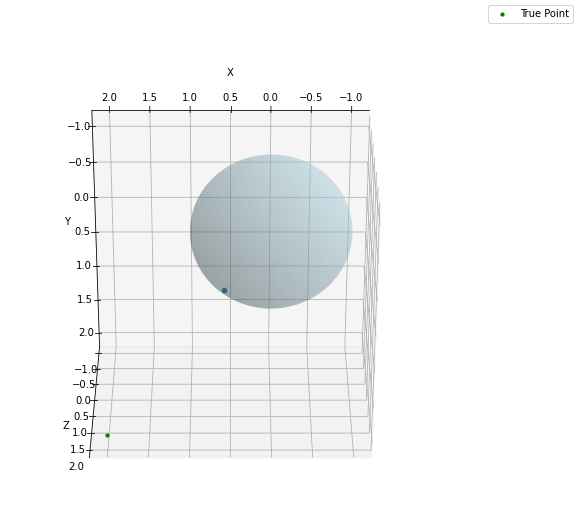

In [31]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import vonmises_fisher

# Function defining the regression mean m_0(theta) on S^2
def m_0(theta, mu):
    """
    Compute the regression mean on S^2.
    
    Parameters:
    theta : array-like
        Angles in [0, 2pi) that parameterize the great circle.
    mu : array-like, shape (2,)
        A unit vector defining the orientation of the great circle.
    
    Returns:
    array, shape (n, 3)
        The mean directions on S^2.
    """
    theta = np.asarray(theta)
    mu = np.asarray(mu)
    assert mu.shape == (2,) and np.isclose(np.linalg.norm(mu), 1), "mu must be a unit vector in R^2"
    
    x1 = np.cos(theta)
    x2 = np.sin(theta) * mu[0]
    x3 = np.sin(theta) * mu[1]
    
    return np.column_stack((x1, x2, x3))

# Function to generate vMF samples
def simulate_data(kappa, mu, theta_samples):
    """
    Generate samples from the von Mises-Fisher distribution on S^2.
    
    Parameters:
    sample_size : int
        Number of samples to generate.
    kappa : float
        Concentration parameter of the vMF distribution.
    mu : array-like, shape (2,)
        The unit vector defining the great circle.
    
    Returns:
    dict
        A dictionary containing input angles and generated samples.
    """
    mean_directions = m_0(theta_samples, mu)  # Compute means on S^2
    
    samples = [vonmises_fisher(mean, kappa).rvs() for mean in mean_directions]
    
    return theta_samples, np.array(samples)

mu = np.array([1/np.sqrt(2), 1/np.sqrt(2)])  # Fixed unit vector in R^2


# Create directory for saving samples
save_folder = os.path.join(os.getcwd(), 'simulations_sphere', 'data')
os.makedirs(save_folder, exist_ok=True)

np.random.seed(1000)
sample_size = 1000
kappa = 200
theta_samples = np.random.uniform(0, 2 * np.pi, sample_size)  # Random angles
theta, Y = simulate_data(kappa, mu, theta_samples)
Y = Y.reshape(-1, 3)
# Plotting the unit sphere
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a mesh grid for the unit sphere
u = np.linspace(0, np.pi, 100)
v = np.linspace(0, 2 * np.pi, 100)
u, v = np.meshgrid(u, v)

x_sphere = np.sin(u) * np.cos(v)
y_sphere = np.sin(u) * np.sin(v)
z_sphere = np.cos(u)

# Plot the sphere surface
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.3)

# Plot the von Mises-Fisher samples on the sphere
#ax.scatter(Y[:, 0], Y[:, 1], Y[:, 2], color='r', s=5, label="vMF Samples")
ax.scatter(2, 2, 2, color = 'green', s = 10, label = 'True Point')
ax.scatter(1/np.sqrt(3), 1/np.sqrt(3), 1/np.sqrt(3))
# Set labels and view
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.view_init(elev=120, azim=90)  # Adjust view angle

fig.legend()
plt.show()

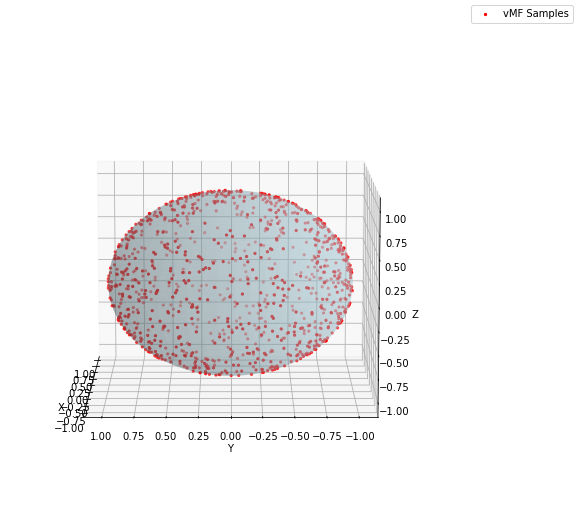

In [4]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import vonmises_fisher

# Function defining the regression mean m_0(theta) on S^2
def m_0(theta, mu):
    """
    Compute the regression mean on S^2.
    
    Parameters:
    theta : array-like
        Angles in [0, 2pi) that parameterize the great circle.
    mu : array-like, shape (2,)
        A unit vector defining the orientation of the great circle.
    
    Returns:
    array, shape (n, 3)
        The mean directions on S^2.
    """
    theta = np.asarray(theta)
    mu = np.asarray(mu)
    assert mu.shape == (2,) and np.isclose(np.linalg.norm(mu), 1), "mu must be a unit vector in R^2"
    
    x1 = np.cos(theta)
    x2 = np.sin(theta) * mu[0]
    x3 = np.sin(theta) * mu[1]
    
    return np.column_stack((x1, x2, x3))

# Function to generate vMF samples
def simulate_data(kappa, mu, theta_samples):
    """
    Generate samples from the von Mises-Fisher distribution on S^2.
    
    Parameters:
    sample_size : int
        Number of samples to generate.
    kappa : float
        Concentration parameter of the vMF distribution.
    mu : array-like, shape (2,)
        The unit vector defining the great circle.
    
    Returns:
    dict
        A dictionary containing input angles and generated samples.
    """
    mean_directions = m_0(theta_samples, mu)  # Compute means on S^2
    
    samples = [vonmises_fisher(mean, kappa).rvs() for mean in mean_directions]
    
    return theta_samples, np.array(samples)

mu = np.array([1/np.sqrt(2), 1/np.sqrt(2)])  # Fixed unit vector in R^2


# Create directory for saving samples
save_folder = os.path.join(os.getcwd(), 'simulations_sphere', 'data')
os.makedirs(save_folder, exist_ok=True)

np.random.seed(1000)
sample_size = 1000
kappa = 200
theta_samples = np.random.uniform(0, 2 * np.pi, sample_size)  # Random angles
theta, Y = simulate_data(kappa, mu, theta_samples)
Y = Y.reshape(-1, 3)
# Plotting the unit sphere
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a mesh grid for the unit sphere
u = np.linspace(0, np.pi, 100)
v = np.linspace(0, 2 * np.pi, 100)
u, v = np.meshgrid(u, v)

x_sphere = np.sin(u) * np.cos(v)
y_sphere = np.sin(u) * np.sin(v)
z_sphere = np.cos(u)

# Plot the sphere surface
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.3)

# Plot the von Mises-Fisher samples on the sphere
#ax.scatter(Y[:, 0], Y[:, 1], Y[:, 2], color='r', s=5, label="vMF Samples")

ax.scatter(new_X[:, 0], new_X[:, 1], new_X[:, 2], color='r', s=5, label="vMF Samples")

#ax.scatter(2, 2, 2, color = 'green', s = 10, label = 'True Point')
#ax.scatter(1/np.sqrt(3), 1/np.sqrt(3), 1/np.sqrt(3))
# Set labels and view
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.view_init(elev=10, azim=180)  # Adjust view angle
 
fig.legend()
plt.show()

In [3]:
X = np.random.multivariate_normal(mean=np.array([0,0,0]), cov=np.eye(3), size = 1000)
norms = np.linalg.norm(X, axis=1).reshape(-1,1)
new_X = X / norms

# Hypersphere 

In [85]:
def runif_sphere(n):
    """
    Generate n uniform random points on the unit sphere.
    
    Parameters:
    n : int
        Number of points to generate.
    
    Returns:
    array, shape (n, 3)
        Random points on the unit sphere.
    """
    X = np.random.multivariate_normal(mean=np.array([0,0]), cov=np.eye(2), size = n)
    norms = np.linalg.norm(X, axis=1).reshape(-1,1)
    return X / norms

def ru(n, kappa):
    cosh_1 = np.random.exponential(1/kappa, size = n)
    return np.arccosh(1 + cosh_1)

def r_vMF(n, kappa):
    """
    Generate n random points from the von Mises-Fisher distribution on S^2.
    
    Parameters:
    n : int
        Number of points to generate.
    mu : array-like, shape (2,)
        The unit vector defining the great circle.
    kappa : float
        Concentration parameter of the vMF distribution.
    
    Returns:
    array, shape (n, 3)
        Random points from the vMF distribution.
    """
    u = ru(n, kappa)
    return np.hstack([np.cosh(u).reshape(n,1), np.sinh(u).reshape(-1,1) * runif_sphere(n) ])

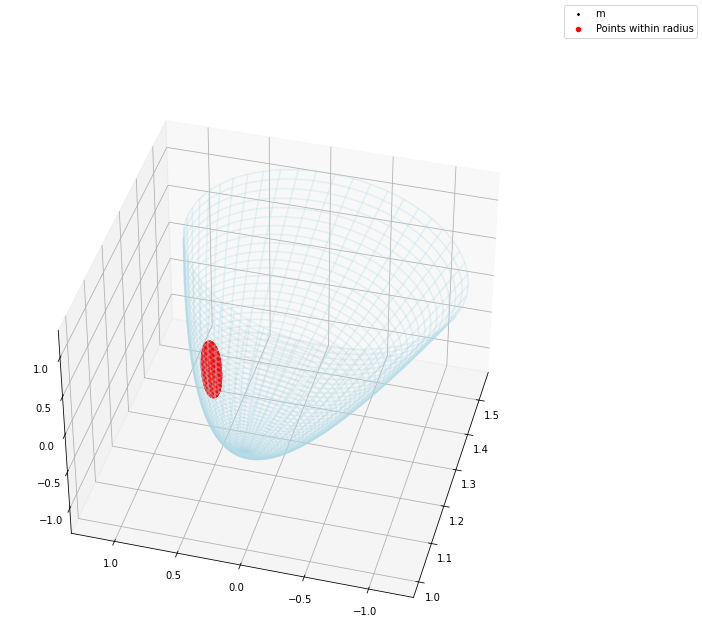

In [86]:
#For hyperboloid
u = np.linspace(0, 1, 1000)
v = np.linspace(0, 2*np.pi, 1000)

u, v = np.meshgrid(u, v)

x_grid = np.cosh(u)
y_grid = np.sinh(u)* np.cos(v)
z_grid = np.sinh(u)* np.sin(v)

# Define the parameter theta
theta = np.linspace(-1, 1, 1000)

# Generate 10 random unit vectors in R2
random_vectors = np.random.randn(3, 2)
random_unit_vectors = random_vectors / np.linalg.norm(random_vectors, axis=1)[:, np.newaxis]# Compute the coordinates of the curve on the hyperboloid

# Plot the hyperboloid surface

# Plot the curve on the hyperboloid


# Set labels and view

fig=plt.figure()
fig.set_size_inches(12, 10)
ax=plt.axes(projection='3d')
#ax.scatter3D(y.data[:,0],
#            y.data[:,1],
#            y.data[:,2], color='blue', label='Reference')
#ax.plot_surface(x_grid, y_grid, z_grid, color='green', alpha=0.35)
ax.plot_wireframe(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3)
#for mu in random_unit_vectors:
#    x_curve = np.cosh(theta)
#    y_curve = np.sinh(theta) * mu[0]
#    z_curve = np.sinh(theta) * mu[1]
#    ax.plot(x_curve, y_curve, z_curve, color='green', label='Curve on Hyperboloid')
ax.view_init(elev=40, azim=195)
# Define the Minkowski pseudo-inner product
def minkowski_inner_product(x, y):
    return -x[0]*y[0] + x[1]*y[1] + x[2]*y[2]

# Define the distance function
def hyperboloid_distance(x, y):
    return np.arccosh(-minkowski_inner_product(x, y))

# Choose a point m on the hyperboloid
m = np.array([np.cosh(0.5), np.sinh(0.5) * np.cos(np.pi/5), np.sinh(0.5) * np.sin(np.pi/5)])

# Define a radius
radius = 0.1

# Find points within the given radius from m
points_within_radius = []
for i in range(x_grid.shape[0]):
    for j in range(x_grid.shape[1]):
        point = np.array([x_grid[i, j], y_grid[i, j], z_grid[i, j]])
        if hyperboloid_distance(m, point) <= radius:
            points_within_radius.append(point)

points_within_radius = np.array(points_within_radius)

# Plot the points within the given radius
ax.scatter(m[0], m[1], m[2], color='black', label='m', s=3)
ax.scatter(points_within_radius[:, 0], points_within_radius[:, 1], points_within_radius[:, 2], color='red', label='Points within radius')
fig.legend()
plt.show()

In [162]:
hyp_points['V1'].max()

1.89859183232931

In [168]:
x_curve.max()

1.8884238771610158

In [195]:
# read hyp_points.csv
import sys, os
import pandas as pd
hyp_points = pd.read_csv(os.path.join(os.getcwd(),'simulations_sphere', 'hyp_points.csv') )
hyp_points.drop(columns = ['Unnamed: 0'], inplace = True)

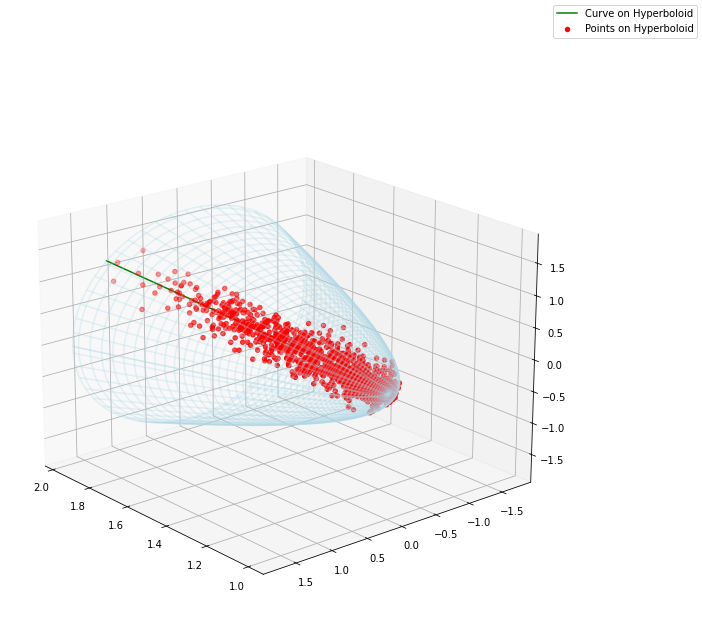

In [198]:
#For hyperboloid
u = np.linspace(0, 1.3, 100)
v = np.linspace(0, 2*np.pi, 100)

u, v = np.meshgrid(u, v)

x_grid = np.cosh(u)
y_grid = np.sinh(u)* np.cos(v)
z_grid = np.sinh(u)* np.sin(v)

# Define the parameter theta
theta = np.linspace(0, 1.3, 100)

# Generate 10 random unit vectors in R2
mu = np.array([1/np.sqrt(2), 1/np.sqrt(2)])  # Fixed unit vector in R^2
# Compute the coordinates of the curve on the hyperboloid

# Set labels and view

fig=plt.figure()
fig.set_size_inches(12, 10)
ax=plt.axes(projection='3d')
#ax.scatter3D(y.data[:,0],
#            y.data[:,1],
#            y.data[:,2], color='blue', label='Reference')
#ax.plot_surface(x_grid, y_grid, z_grid, color='green', alpha=0.35)
ax.plot_wireframe(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3)

x_curve = np.cosh(theta)
y_curve = np.sinh(theta) * mu[0]
z_curve = np.sinh(theta) * mu[1]
ax.plot(x_curve, y_curve, z_curve, color='green', label='Curve on Hyperboloid')
# plot hyp_points on the hyperboloid
ax.scatter(hyp_points['V1'], hyp_points['V2'], hyp_points['V3'], color='red', label='Points on Hyperboloid')

ax.view_init(elev=20, azim=140)
fig.legend()

plt.show()

In [98]:
hyp_points

,V1,V2,V3
0,5.812812,-3.223981,4.732307
1,1.641370,-0.446336,1.222652
2,1.037459,-0.247229,-0.123286
3,6.575038,-6.474864,-0.554307
4,4.961370,-4.002785,-2.755523
...,...,...,...
622,1.987067,1.311193,1.108697
623,3.760242,2.411027,2.706726
624,1.723589,0.970699,1.014152
625,2.737643,1.814046,1.789951


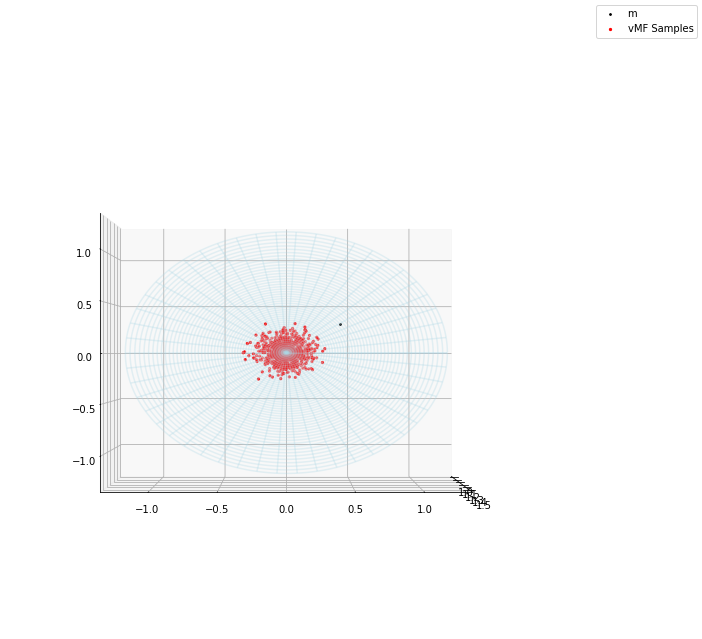

In [266]:
 #For hyperboloid
u = np.linspace(0, 1, 1000)
v = np.linspace(0, 2*np.pi, 1000)

u, v = np.meshgrid(u, v)

x_grid = np.cosh(u)
y_grid = np.sinh(u)* np.cos(v)
z_grid = np.sinh(u)* np.sin(v)

# Define the parameter theta
theta = np.linspace(-1, 1, 1000)

# Generate 10 random unit vectors in R2
random_vectors = np.random.randn(3, 2)
random_unit_vectors = random_vectors / np.linalg.norm(random_vectors, axis=1)[:, np.newaxis]# Compute the coordinates of the curve on the hyperboloid

# Plot the hyperboloid surface

# Set labels and view

fig=plt.figure()
fig.set_size_inches(12, 10)
ax=plt.axes(projection='3d')

ax.plot_wireframe(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3)


ax.view_init(elev=-0, azim=0)
# Define the Minkowski pseudo-inner product
def minkowski_inner_product(x, y):
    return -x[0]*y[0] + x[1]*y[1] + x[2]*y[2]

# Define the distance function
def hyperboloid_distance(x, y):
    return np.arccosh(-minkowski_inner_product(x, y))

# Choose a point m on the hyperboloid
m = np.array([np.cosh(0.5), np.sinh(0.5) * np.cos(np.pi/5), np.sinh(0.5) * np.sin(np.pi/5)])





# Plot the points within the given radius
ax.scatter(m[0], m[1], m[2], color='black', label='m', s=3)
# ax.scatter(points_within_radius[:, 0], points_within_radius[:, 1], points_within_radius[:, 2], color='red', label='Points within radius')

n= 1000
kappa = 100
new_X = r_vMF(n, kappa)
ax.scatter(new_X[:, 0], new_X[:, 1], new_X[:, 2], color='r', s=5, label="vMF Samples")

fig.legend()
plt.show()

In [301]:
import numpy as np
from scipy.integrate import dblquad

# Fixed parameters
kappa = 1.0  # example value for kappa
chi = .5   # example value for chi
theta = 3.0  # example value for theta

# Define the density function
def density(u, w):
    norm_const = (kappa * np.exp(kappa)) / (2 * np.pi)
    return norm_const * np.sinh(u) * np.exp(-kappa * (np.cosh(chi) * np.cosh(u) - np.sinh(chi) * np.sinh(u) * np.cos(w - theta)))

# Define the CDF function that integrates the density function
def cdf(u, w):
    # Perform the integration over u from -inf to u, and w from -pi to w
    result, _ = dblquad(density, 0, w, 0, u)
    return result

# Example usage:
u_value = 10  # Example value for u
w_value = 5  # Example value for w
cdf_value = cdf(u_value, w_value)

print(f"The CDF at u={u_value}, w={w_value} is: {cdf_value}")


The CDF at u=10, w=5 is: 0.9082582001388682


In [303]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import dblquad
from scipy.stats import rv_continuous

# Fixed parameters
kappa = 1.0  # example value for kappa
chi = 1.0    # example value for chi
theta = 1.0  # example value for theta

# Define the density function
def density(u, w):
    norm_const = (kappa * np.exp(kappa)) / (2 * np.pi)
    return norm_const * np.sinh(u) * np.exp(-kappa * (np.cosh(chi) * np.cosh(u) - np.sinh(chi) * np.sinh(u) * np.cos(w - theta)))

# Define the CDF function that integrates the density function
def cdf(u, w):
    # Perform the integration over u from -inf to u, and w from -pi to w
    result, _ = dblquad(density, -np.pi, w, -np.inf, u)
    return result

# Create a custom random variable class
class MyBivariateRandomVariable(rv_continuous):
    def __init__(self, xtol=1e-14, seed=None):
        super().__init__(a=-np.inf, b=np.inf, xtol=xtol, seed=seed)
    
    def _cdf(self, u, w):
        # We need to return the CDF for this bivariate case
        return cdf(u, w)

    def _rvs(self, size=1):
        # Sampling using inverse transform method (numerically)
        samples = []
        for _ in range(size):
            u_sample = np.random.uniform(-np.inf, np.inf)  # We need to sample u in the proper range
            w_sample = np.random.uniform(-np.pi, np.pi)  # We need to sample w in the proper range
            samples.append((u_sample, w_sample))
        return np.array(samples)

# Main execution to sample and visualize
if __name__ == "__main__":
    # Instantiate the bivariate RV class
    my_bivariate_rv = MyBivariateRandomVariable()

    # Sample from the distribution
    samples = my_bivariate_rv.rvs(size=1000)

    # Plotting
    fig, ax1 = plt.subplots()

    # Scatter plot of the sampled points
    ax1.scatter(samples[:, 0], samples[:, 1], alpha=0.5, s=10)

    # Define grid for PDF and CDF plotting
    u_vals = np.linspace(-3, 3, 100)
    w_vals = np.linspace(-np.pi, np.pi, 100)
    U, W = np.meshgrid(u_vals, w_vals)

    # Plot the PDF and CDF (for visualization)
    Z_pdf = np.array([density(u, w) for u, w in zip(np.ravel(U), np.ravel(W))]).reshape(U.shape)
    Z_cdf = np.array([cdf(u, w) for u, w in zip(np.ravel(U), np.ravel(W))]).reshape(U.shape)

    ax2 = ax1.twinx()
    ax2.contourf(U, W, Z_pdf, 20, cmap='Blues', alpha=0.5)
    ax2.contourf(U, W, Z_cdf, 20, cmap='Oranges', alpha=0.5)

    ax1.set_xlabel('u')
    ax1.set_ylabel('w')
    ax2.set_ylabel('Density & CDF')

    fig.tight_layout()
    plt.show()


TypeError: _parse_args_rvs() missing 1 required positional argument: 'w'

In [302]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

class MyRandomVariableClass(stats.rv_continuous):
    def __init__(self, xtol=1e-14, seed=None):
        super().__init__(a=0, xtol=xtol, seed=seed)

    def _cdf(self, x):
        return 1-np.exp(-x**2)


if __name__ == "__main__":
    my_rv = MyRandomVariableClass()

    # sample distribution
    samples = my_rv.rvs(size = 1000)

    # plot histogram of samples
    fig, ax1 = plt.subplots()
    ax1.hist(list(samples), bins=50)

    # plot PDF and CDF of distribution
    pts = np.linspace(0, 5)
    ax2 = ax1.twinx()
    ax2.set_ylim(0,1.1)
    ax2.plot(pts, my_rv.pdf(pts), color='red')
    ax2.plot(pts, my_rv.cdf(pts), color='orange')

    fig.tight_layout()
    plt.show()

TypeError: _parse_args_rvs() missing 1 required positional argument: 'w'

In [1]:
import numpy as np
from scipy.integrate import quad

# Define the function to integrate, depending on w, x, and z
def integrand(w, x, z):
    return np.exp(-w**2) * np.sin(x) + z

# Function to integrate with respect to w, while x and z are parameters
def integrate_function(x, z, w1, w2):
    # Integrate the function with respect to w over the range [w1, w2]
    result, error = quad(integrand, w1, w2, args=(x, z))
    return result

# Example values for x, z, and integration limits
x = 1.0
z = 2.0
w1 = -5
w2 = 5

# Perform the integration
integral_result = integrate_function(x, z, w1, w2)

print(f"Integral result: {integral_result}")


Integral result: 21.491468487445722


In [7]:
import sympy as sp

# Define symbolic variables
w, x, theta, C = sp.symbols('w x theta C')

# Define the integrand, assuming f(w, x, z) = exp(-w^2) * sin(x) + z
integrand = sp.exp(C * sp.cos(w - theta))

# Perform the symbolic integration with respect to w
integral_result = sp.integrate(integrand, (w, 0, 2*sp.pi))

# Display the result
print("Symbolic integral result:", integral_result)


Symbolic integral result: Integral(exp(C*cos(theta - w)), (w, 0, 2*pi))


Sampled u values: [0.36728902 0.15756507 0.51155685 1.0798257  0.70277182 0.76248348
 0.36977354 0.37950134 0.50124692 0.46211275 1.32977096 0.37660321
 0.56085089 0.79073603 0.14763049 0.4532085  0.75724674 0.43877524
 0.40188511 1.04048159 0.52662851 0.63391503 0.43545723 0.37422997
 0.57619149 0.97831656 0.25206472 0.57643209 0.87247826 0.45397958
 1.06117415 0.45134316 1.13362574 0.4330731  0.38086738 0.4378844
 0.34157222 1.1025465  0.47620749 2.11620495 0.53956497 1.05492327
 0.43060364 0.09912664 0.08092917 0.83413987 0.68075247 0.28809963
 0.64811521 0.53344238 0.63990422 0.18337075 0.20845781 0.5559113
 0.52473817 0.55830575 0.17753643 0.81743642 0.62615629 0.5753553
 0.3428369  0.84921615 0.80381282 1.39654675 1.45207917 0.85712006
 0.6028352  0.26060753 0.33244403 0.68979353 0.11526686 0.90354888
 0.50083691 0.28499197 0.47339044 0.05964283 0.86909747 0.15686693
 0.47902463 0.91754107 0.4833119  0.51677643 0.8300205  0.70391009
 0.48159735 0.48728494 0.40572603 0.00790932 0.

In [43]:
integrate.quad(lambda u: f_u(u, kappa, chi), 0, 5)

(0.9999999999999996, 9.443718987367511e-09)

In [69]:
from typing import List
import scipy.integrate as integrate
import numpy as np
from scipy.special import i0  # Modified Bessel function of the first kind

def f_u(u, kappa, chi):
    """
    Unnormalized marginal density for u.
    """
    return kappa*np.exp(kappa)*np.sinh(u)*np.exp(-kappa*(np.cosh(chi)*np.cosh(u))) * i0(kappa*np.sinh(chi)*np.sinh(u))
    
def cdf(ub_ls:List[float], kappa, chi) -> List:
    results = []
    # loop through all upper bounds
    for ub in ub_ls:
        results.append(integrate.quad(f_u, 0, ub, args=(kappa, chi))[0])
    return results

kappa = 3
chi = 1

In [84]:
i0(5)

27.239871823604442